# 02 — Descomposición y features: King Crimson

1. Descomposición estacional (`statsmodels.tsa.seasonal_decompose` o STL) por
   isla, sobre la serie armonizada de `01_eda.ipynb`.
2. Aplicar `src/features.py` (`build_features`) para generar calendario,
   rezagos y medias móviles — necesarios para el modelo de LightGBM (SARIMA
   no los necesita, trabaja directo sobre la serie).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

from src.data import load_harmonized_series, to_wide_by_island
from src.features import build_features

df = load_harmonized_series()
df_features = build_features(df, target_col="revpar_eur")
df_features.head()

,fecha,isla,adr_eur,revpar_eur,grado_ocupacion,month,quarter,is_high_season,revpar_eur_lag_1,revpar_eur_lag_3,revpar_eur_lag_12,revpar_eur_rolling_mean_3,revpar_eur_rolling_mean_12,revpar_eur_yoy_growth
0,2009-01-01,El Hierro,56.55,8.38,0.148187,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-02-01,El Hierro,58.57,10.26,0.175175,2,1,1,8.38,NaN,NaN,NaN,NaN,NaN
2,2009-03-01,El Hierro,60.87,11.75,0.193034,3,1,1,10.26,NaN,NaN,NaN,NaN,NaN
3,2009-04-01,El Hierro,66.49,21.12,0.317642,4,2,0,11.75,8.38,NaN,10.130000,NaN,NaN
4,2009-05-01,El Hierro,67.40,14.48,0.214837,5,2,0,21.12,10.26,NaN,14.376667,NaN,NaN


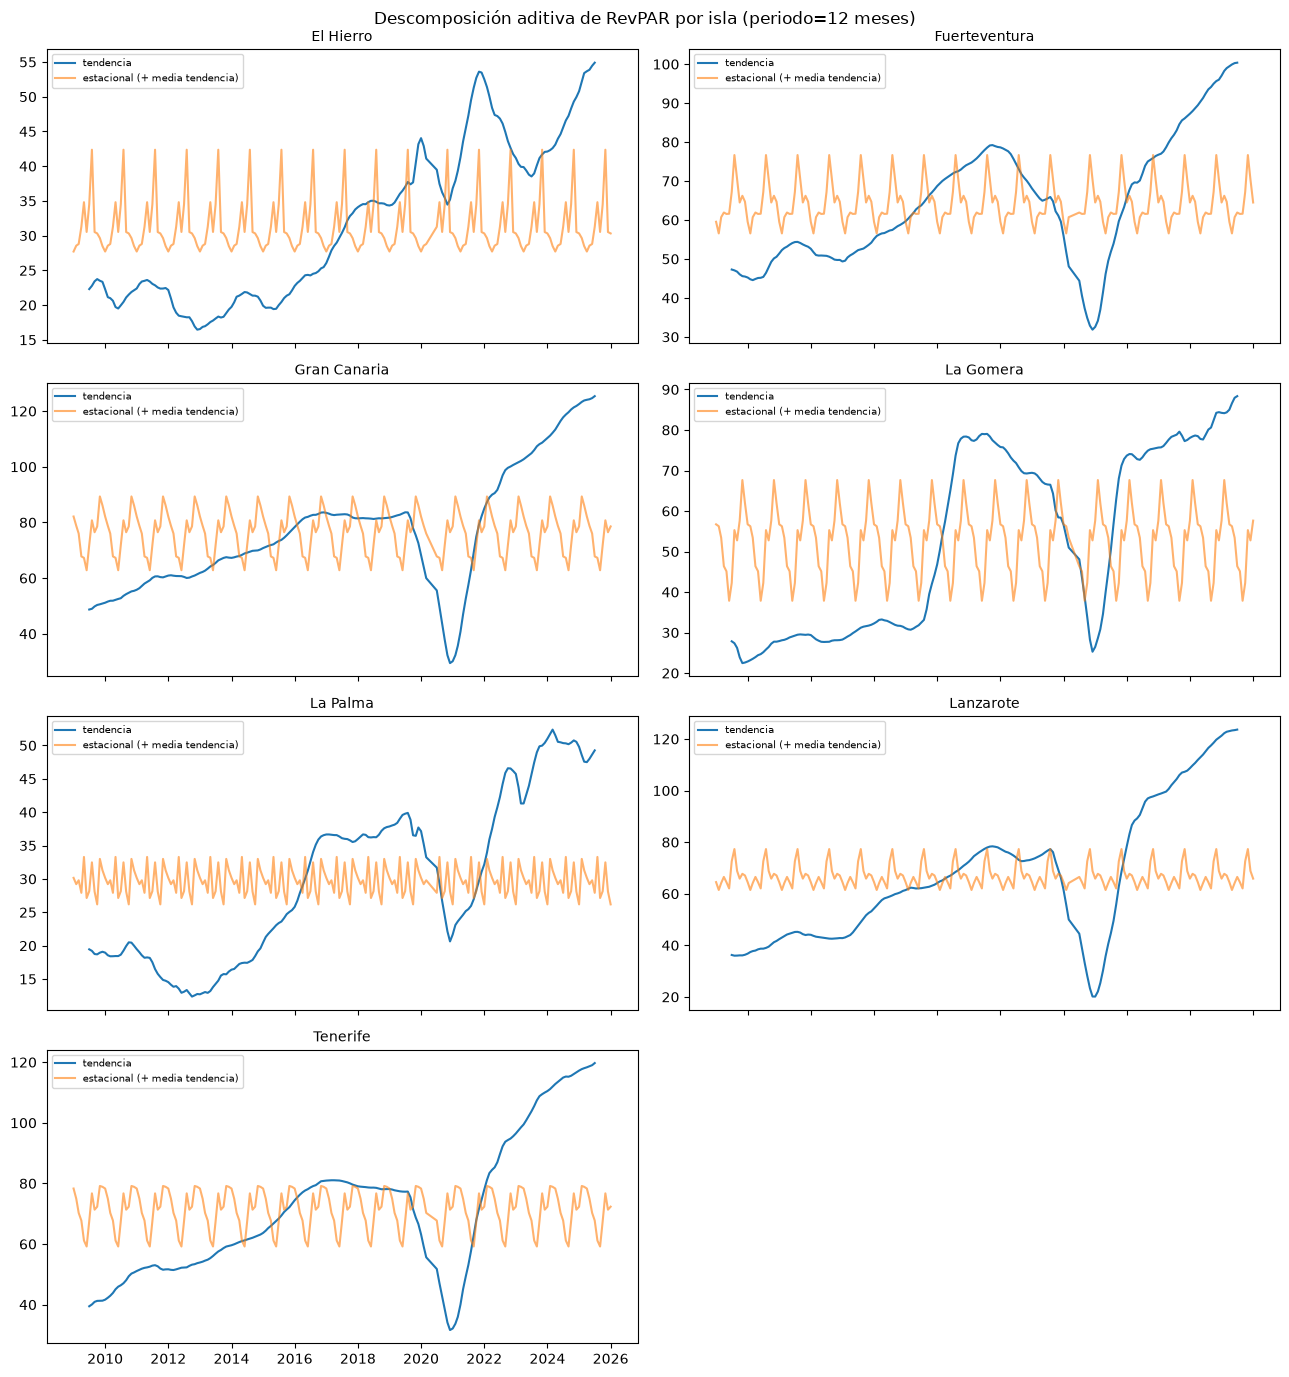

In [2]:
wide = to_wide_by_island(df, "revpar_eur")

fig, axes = plt.subplots(4, 2, figsize=(13, 14), sharex=True)
for ax, isla in zip(axes.flat, wide.columns):
    result = seasonal_decompose(wide[isla].dropna(), model="additive", period=12)
    ax.plot(result.trend, label="tendencia")
    ax.plot(result.seasonal + result.trend.mean(), label="estacional (+ media tendencia)", alpha=0.6)
    ax.set_title(isla, fontsize=10)
    ax.legend(fontsize=7, loc="upper left")

axes.flat[-1].axis("off")
plt.suptitle("Descomposición aditiva de RevPAR por isla (periodo=12 meses)")
plt.tight_layout()
Path("reports/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("reports/figures/02_decomposicion_estacional.png", dpi=110, bbox_inches="tight")
plt.show()

In [3]:
print(f"Filas antes de descartar warm-up de lags/rolling: {len(df_features)}")

usable = df_features.dropna(subset=[c for c in df_features.columns if "lag_" in c or "rolling_" in c])
print(f"Filas utilizables tras descartar warm-up (necesita lag_12 + rolling_12): {len(usable)}")
print(f"Se pierden los primeros 12 meses por isla (7 islas x 12 = 84 filas) por diseño: nunca hay fuga de futuro.")

output_path = Path("data/processed/canarias_features.csv")
df_features.to_csv(output_path, index=False)
print(f"\nGuardado (incluye NaNs de warm-up, tal cual las genera build_features) en {output_path}")
df_features[df_features["isla"] == "Tenerife"].tail()

Filas antes de descartar warm-up de lags/rolling: 1414
Filas utilizables tras descartar warm-up (necesita lag_12 + rolling_12): 1330
Se pierden los primeros 12 meses por isla (7 islas x 12 = 84 filas) por diseño: nunca hay fuga de futuro.

Guardado (incluye NaNs de warm-up, tal cual las genera build_features) en data/processed/canarias_features.csv


,fecha,isla,adr_eur,revpar_eur,grado_ocupacion,month,quarter,is_high_season,revpar_eur_lag_1,revpar_eur_lag_3,revpar_eur_lag_12,revpar_eur_rolling_mean_3,revpar_eur_rolling_mean_12,revpar_eur_yoy_growth
1409,2025-09-01,Tenerife,128.68,107.60,0.836183,9,3,1,123.32,95.51,105.59,110.596667,117.940000,0.019036
1410,2025-10-01,Tenerife,141.37,119.67,0.846502,10,4,0,107.60,112.96,114.72,114.626667,118.107500,0.043149
1411,2025-11-01,Tenerife,151.11,132.33,0.875720,11,4,1,119.67,123.32,129.45,116.863333,118.520000,0.022248
1412,2025-12-01,Tenerife,171.63,138.32,0.805920,12,4,0,132.33,107.60,132.19,119.866667,118.760000,0.046373
1413,2026-01-01,Tenerife,169.45,142.77,0.842549,1,1,1,138.32,119.67,132.20,130.106667,119.270833,0.079955
